In [1]:
import pytrends
import datetime
import time

import polars as pl
import matplotlib.pyplot as plt

In [2]:
from pytrends.request import TrendReq
request = TrendReq()

In [3]:
request.build_payload(['Facebook'], cat=0, timeframe = '2020-07-01 2020-07-08', geo = 'GB', gprop = '')
request.interest_over_time()

,Facebook,isPartial
date,,
2020-07-01,93,False
2020-07-02,94,False
2020-07-03,89,False
2020-07-04,100,False
2020-07-05,98,False
2020-07-06,94,False
2020-07-07,90,False
2020-07-08,92,False


In [4]:
def load_trend_window(candidate, country, start_date, end_date):
    '''
    There are better ways to handle this, I wanted to show what code looks like when you're
    putting in incremental hacks to combat data loading nightmares!
    '''
    date_range_str = f'{start_date.strftime("%Y-%m-%d")} {end_date.strftime("%Y-%m-%d")}'
    try:
        print(candidate)
        print(date_range_str)
        request.build_payload([candidate], cat=0, timeframe=date_range_str, geo=country, gprop='')
    except Exception as e:
        if '429' in str(e) or 'TooManyRequestsError' in str(e):
            print(f"Rate limited on {date_range_str}, sleeping for 60 seconds...")
            time.sleep(60)  # wait 60 seconds on rate limit
            try:
                request.build_payload([candidate], cat=0, timeframe=date_range_str, geo=country, gprop='')
            except Exception as e:
                if '429' in str(e) or 'TooManyRequestsError' in str(e):
                    print(f"Rate limited on {date_range_str}, sleeping for 60 seconds...")
                    time.sleep(60)  # wait 60 seconds on rate limit
                    request.build_payload([candidate], cat=0, timeframe=date_range_str, geo=country, gprop='')
            else:
                raise e
        else:
            raise e

    output = request.interest_over_time()
    return output

In [42]:
trend_output = load_trend_window('Google Translate', 'GB', datetime.date(2020,7,1), datetime.date(2020,7,8))
trend_output

Google Translate
2020-07-01 2020-07-08


,Google Translate,isPartial
date,,
2020-07-01,100,False
2020-07-02,98,False
2020-07-03,87,False
2020-07-04,61,False
2020-07-05,60,False
2020-07-06,94,False
2020-07-07,97,False
2020-07-08,95,False


In [6]:
def trend_window_to_table(output, candidate, batch_number):
    output_table = pl.DataFrame({
        'date': output.index, 
        candidate: output[candidate], 
        f'isPartial_{candidate}': output['isPartial'],
        'batch_number': [batch_number]*len(output[candidate]),
    })
    return output_table

In [7]:
reformatted_trend_output = trend_window_to_table(trend_output, 'Google Translate', 1)
reformatted_trend_output

date,Google Translate,isPartial_Google Translate,batch_number
datetime[ns],i64,bool,i64
2020-07-01 00:00:00,100,false,1
2020-07-02 00:00:00,100,false,1
2020-07-03 00:00:00,88,false,1
2020-07-04 00:00:00,62,false,1
2020-07-05 00:00:00,62,false,1
2020-07-06 00:00:00,99,false,1
2020-07-07 00:00:00,96,false,1
2020-07-08 00:00:00,94,false,1


In [8]:
basket_candidates = ['YouTube',
                     'Amazon', 
                     'Facebook', 
                     'WhatsApp Web', 
                     #'Translate', # The term doesn't seem to work!
                     'Instagram', 
                     'Gmail', 
                     'Google', 
                     'Weather', 
                     'Google Translate', 
                    ]
all_terms = basket_candidates + ['Motivation']
countries = ['US', 
             'GB', 
             'IN',
             'BR', 
             'DE', 
             'JP'
            ]  
term_to_topic = {'YouTube': '/m/09jcvs',
                 'Amazon': '/g/11cm12hhlm',
                 'Facebook': '/m/02y1vz', 
                 'WhatsApp Web': '/m/0gwzvs1',
                 'Translate': '/g/11wjz30z8z',
                 'Instagram': '/m/0glpjll',
                 'Gmail': '/m/02q_bk',
                 'Google': '/g/11c59p0g8n',
                 'Weather': '/m/0866r',
                 'Google Translate': '/m/025sndk',
                 'Motivation': '/m/01ht4f',
                }
is_topic = False

In [9]:
def run_and_save_part(part_number, part_start_date, part_end_date, batch_number):
    start_date = part_start_date
    end_date = start_date + datetime.timedelta(days=90)

    country_kw_tables = []
    while end_date < part_end_date:
        output = load_trend_window(term, country, start_date, end_date)
        output_table = format_table(output, term, batch_number)
        country_kw_tables.append(output_table)
        batch_number += 1

        # Wait 5 seconds between requests to avoid rate limiting
        time.sleep(15)

        start_date = start_date + datetime.timedelta(days=60) # One month overlap
        end_date = start_date + datetime.timedelta(days=90)

    country_kw_table = pl.concat(country_kw_tables)
    print(country_kw_table)
    country_kw_table.write_csv(f'{country}_{term}_topic_part{part_number}.csv')

In [10]:
def load_trends_data(terms):
    for term in terms:
        candidate = term_to_topic[term]
        print(term)
        for country in countries:
            print(country)
            
            ### I am not proud of this hack
            run_part_1 = True
            run_part_2 = True
            run_part_3 = True
            if term == 'Motivation' and country != 'JP':
                run_part_1 = False
                run_part_2 = False
                run_part_3 = False
            if term == 'Google Translate' and country in ['JP']:
                run_part_1 = False
                run_part_2 = False
                run_part_3 = True
                
            if run_part_1: 
                batch_number = 1
                start_date = datetime.date(2020, 7, 1)
                end_date = datetime.date(2022, 2, 21)
                run_and_save_part(1, part_start_date, part_end_date, batch_number)
            if run_part_2:
                batch_number = 10
                start_date = datetime.date(2021, 12, 23)
                end_date = datetime.date(2023, 7, 1)
                run_and_save_part(2, part_start_date, part_end_date, batch_number)
            if run_part_3:
                batch_number = 18
                start_date = datetime.date(2023,4,17)
                end_date = datetime.date(2025, 7, 1)
                run_and_save_part(3, part_start_date, part_end_date, batch_number)
            

In [12]:
def combine_data_tables(countries, basket_candidates, is_topic):
    # First because we can only load so much from google trends in one go things are often getting saved in part 1 and part 2, so let's combine them
    def get_path_name(is_topic, part):
        if part == 0:
            if is_topic:
                return f'topics/{country}_{candidate}_topic.csv'
            else:
                return f'with_overlap/{country}_{candidate}.csv'
        else:
            if is_topic:
                return f'topics/{country}_{candidate}_topic_part{part}.csv'
            else:
                return f'with_overlap/{country}_{candidate}_part{part}.csv'
    for country in countries:
        print(country)
        for candidate in basket_candidates:
            full_table_path = get_path_name(is_topic, 0)
            try:
                df = pl.read_csv(full_table_path)
                continue
            except Exception as e:
                dfs = []
                file_path1 = get_path_name(is_topic, 1)
                df1 = pl.read_csv(file_path1)
                dfs.append(df1)
                file_path2 = get_path_name(is_topic, 2)
                df2 = pl.read_csv(file_path2)
                dfs.append(df2)
                file_path3 = get_path_name(is_topic, 3)
                try:
                    df3 = pl.read_csv(file_path3)
                    dfs.append(df3)
                except Exception as e:
                    print(f'No part 3 for {country} {candidate}')
                df = pl.concat(dfs)
                if is_topic:
                    final_name = f'topics/{country}_{candidate}_topic.csv'
                else:
                    final_name = f'with_overlap/{country}_{candidate}.csv'
            df.write_csv(final_name)

In [13]:
combine_data_tables(countries, all_terms, is_topic)

US
GB
IN
BR
DE
JP


In [14]:
def load_all_country_data(terms_to_load, countries, is_topic):
    country_tables = {}
    for country in countries:
        country_table = None
        for candidate in terms_to_load:
            if is_topic:
                file_path = f'topics/{country}_{candidate}_topic.csv'
            else:
                file_path = f'with_overlap/{country}_{candidate}.csv'
            df = pl.read_csv(file_path)
            df = format_table(df, candidate, is_topic)
            if country_table is None:
                country_table = df
            else:
                country_table = country_table.join(df, on = ['date', 'batch_number'], how = 'outer')
        country_tables[country] = country_table
    return country_tables

In [20]:
def format_table(df, candidate, is_topic):
    topic_to_term = dict(zip(term_to_topic.values(), term_to_topic.keys()))
    if is_topic:
        if candidate not in df.columns:
            col_name = [c for c in df.columns if c in topic_to_term.keys()][0]
            df = df.rename({col_name: candidate})
    df = df.with_columns(df['date'].str.strptime(pl.Datetime, format = "%Y-%m-%dT%H:%M:%S.000000000"))
    df = df.with_columns(df[candidate].cast(pl.Int32))
    if 'batch_number' in df.columns:
        df = df.with_columns(df['batch_number'].cast(pl.Int32))
    df = df.drop(*[c for c in df.columns if 'isPartial' in c])
    return df

In [21]:
country_tables = load_all_country_data(all_terms, countries, is_topic)
country_tables['US']

date,batch_number,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation
datetime[μs],i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
2020-07-01 00:00:00,1,76,100,91,89,89,61,30,73,48,44
2020-07-02 00:00:00,1,73,95,89,85,86,57,28,68,48,38
2020-07-03 00:00:00,1,74,90,87,74,84,46,25,73,42,37
2020-07-04 00:00:00,1,76,85,95,54,93,36,23,71,40,35
2020-07-05 00:00:00,1,75,90,100,50,98,38,23,76,39,37
2020-07-06 00:00:00,1,70,91,87,90,95,58,30,79,46,58
2020-07-07 00:00:00,1,71,96,90,78,94,58,31,79,47,45
2020-07-08 00:00:00,1,72,95,86,90,95,60,30,78,47,43
2020-07-09 00:00:00,1,72,91,87,83,90,58,30,75,47,44


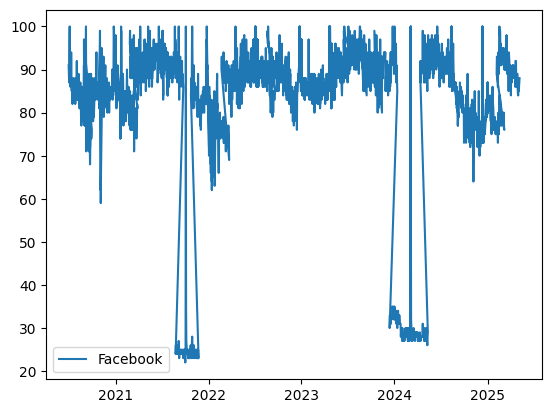

In [22]:
plt.plot(country_tables['US']['date'], country_tables['US']['Facebook'], label = 'Facebook')
plt.legend()

In [23]:
df = country_tables['US']
df = df.with_columns(count = 1)
count_group = df.group_by('date').agg([pl.col('count').sum()]).sort('date')
count_group[0:92]

date,count
datetime[μs],i32
2020-07-01 00:00:00,1
2020-07-02 00:00:00,1
2020-07-03 00:00:00,1
2020-07-04 00:00:00,1
2020-07-05 00:00:00,1
2020-07-06 00:00:00,1
2020-07-07 00:00:00,1
2020-07-08 00:00:00,1
2020-07-09 00:00:00,1


In [24]:
dupe_dates = count_group.filter(count_group['count']>1).sort('count')
dupe_dates

date,count
datetime[μs],i32
2020-08-30 00:00:00,2
2020-08-31 00:00:00,2
2020-09-01 00:00:00,2
2020-09-02 00:00:00,2
2020-09-03 00:00:00,2
2020-09-04 00:00:00,2
2020-09-05 00:00:00,2
2020-09-06 00:00:00,2
2020-09-07 00:00:00,2


In [25]:
dupes = df.filter(df['date'].is_in(dupe_dates['date']))
dupes

date,batch_number,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation,count
datetime[μs],i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
2020-08-30 00:00:00,1,83,89,91,50,88,46,30,78,46,44,1
2020-08-31 00:00:00,1,90,89,78,81,90,88,64,69,78,86,1
2020-09-01 00:00:00,1,93,85,77,79,96,91,71,70,84,66,1
2020-09-02 00:00:00,1,94,81,78,86,79,92,65,66,81,63,1
2020-09-03 00:00:00,1,93,82,77,83,84,89,73,62,83,61,1
2020-09-04 00:00:00,1,91,81,77,84,80,82,60,62,80,56,1
2020-09-05 00:00:00,1,85,87,83,54,87,44,29,76,48,39,1
2020-09-06 00:00:00,1,83,88,86,50,93,43,28,90,43,40,1
2020-09-07 00:00:00,1,81,92,94,74,92,52,34,92,49,52,1


In [26]:
dupes_batches = dupes.group_by('date').agg(pl.col("batch_number").explode()).sort("date")
dupes_batches

date,batch_number
datetime[μs],list[i32]
2020-08-30 00:00:00,"[1, 2]"
2020-08-31 00:00:00,"[1, 2]"
2020-09-01 00:00:00,"[1, 2]"
2020-09-02 00:00:00,"[1, 2]"
2020-09-03 00:00:00,"[1, 2]"
2020-09-04 00:00:00,"[1, 2]"
2020-09-05 00:00:00,"[1, 2]"
2020-09-06 00:00:00,"[1, 2]"
2020-09-07 00:00:00,"[1, 2]"


In [27]:
i = 1
j = i + 1
current_dates_of_interest = dupes_batches.filter((pl.col('batch_number').list.contains(i) & pl.col('batch_number').list.contains(j)))
current_dates_of_interest

date,batch_number
datetime[μs],list[i32]
2020-08-30 00:00:00,"[1, 2]"
2020-08-31 00:00:00,"[1, 2]"
2020-09-01 00:00:00,"[1, 2]"
2020-09-02 00:00:00,"[1, 2]"
2020-09-03 00:00:00,"[1, 2]"
2020-09-04 00:00:00,"[1, 2]"
2020-09-05 00:00:00,"[1, 2]"
2020-09-06 00:00:00,"[1, 2]"
2020-09-07 00:00:00,"[1, 2]"


In [28]:
# Why not this? Because it'll grab the 2s that are in the 2-3 overlap as well as the 1-2 overlap. We don't want them! 
dupes.filter((pl.col('batch_number') == 1)|(pl.col('batch_number')==2))

date,batch_number,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation,count
datetime[μs],i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
2020-08-30 00:00:00,1,83,89,91,50,88,46,30,78,46,44,1
2020-08-31 00:00:00,1,90,89,78,81,90,88,64,69,78,86,1
2020-09-01 00:00:00,1,93,85,77,79,96,91,71,70,84,66,1
2020-09-02 00:00:00,1,94,81,78,86,79,92,65,66,81,63,1
2020-09-03 00:00:00,1,93,82,77,83,84,89,73,62,83,61,1
2020-09-04 00:00:00,1,91,81,77,84,80,82,60,62,80,56,1
2020-09-05 00:00:00,1,85,87,83,54,87,44,29,76,48,39,1
2020-09-06 00:00:00,1,83,88,86,50,93,43,28,90,43,40,1
2020-09-07 00:00:00,1,81,92,94,74,92,52,34,92,49,52,1


In [29]:
dupes_subset = dupes.filter(dupes['date'].is_in(current_dates_of_interest['date']))
dupes_subset_groupby = dupes_subset.group_by('batch_number').agg([pl.col(candidate).mean() for candidate in all_terms])
dupes_subset_groupby

batch_number,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,66.903226,55.354839,83.16129,79.612903,89.774194,73.225806,57.451613,76.129032,75.935484,63.83871
1,90.548387,84.709677,77.903226,75.387097,86.645161,73.225806,57.451613,71.0,75.935484,63.83871


In [30]:
batch_i_average = dupes_subset_groupby.filter(dupes_subset_groupby['batch_number']==i)
batch_j_average = dupes_subset_groupby.filter(dupes_subset_groupby['batch_number']==j)
div = batch_i_average/batch_j_average # scaling factor to match batch j to batch i
div = div.with_columns(scaling_factor_for_batch = j)
div = div.drop('batch_number')
div

YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation,scaling_factor_for_batch
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
1.353423,1.530303,0.936773,0.946921,0.965146,1.0,1.0,0.932627,1.0,1.0,2


In [31]:
def get_scaling_factor_between_batches(dupes_batches, # batch numbers for dates that occur twice
                                       dupes, # df of dates that occur twice
                                       max_batch, 
                                       all_terms):
    '''
    This could be rewritten vectorised
    '''
    scaling_factors = []
    for i in range(1, max_batch):
        j = i + 1
        current_dates_of_interest = dupes_batches.filter((pl.col('batch_number').list.contains(i))&(pl.col('batch_number').list.contains(j)))
        dupes_subset = dupes.filter(dupes['date'].is_in(current_dates_of_interest['date']))
        dupes_subset_groupby = dupes_subset.group_by('batch_number').agg([pl.col(candidate).mean() for candidate in all_terms])
        batch_i_average = dupes_subset_groupby.filter(dupes_subset_groupby['batch_number']==i)
        batch_j_average = dupes_subset_groupby.filter(dupes_subset_groupby['batch_number']==j)
        div = batch_i_average/batch_j_average
        div = div.with_columns(scaling_factor_for_batch = j)
        div = div.drop('batch_number')
        scaling_factors.append(div)
    sf = pl.concat(scaling_factors)
    sf = sf.select(['scaling_factor_for_batch'] + all_terms) # Change order of columns
    return sf

In [32]:
sf = get_scaling_factor_between_batches(dupes_batches, dupes, 28, all_terms)
sf

scaling_factor_for_batch,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,1.353423,1.530303,0.936773,0.946921,0.965146,1.0,1.0,0.932627,1.0,1.0
3,1.0,0.905933,0.951709,0.957846,1.006923,0.662031,0.393727,1.251763,0.706081,0.89984
4,0.59979,0.738872,0.994386,1.10994,1.086902,1.096967,0.91261,1.66005,0.962431,0.963197
5,0.952876,0.898837,0.860408,1.107947,1.0,1.0,0.985424,0.555786,0.96374,1.015756
6,1.041989,1.36053,0.978656,1.027569,0.807458,0.759287,1.181281,1.094017,0.931072,0.881129
7,0.927505,0.671574,1.001058,1.0,1.007738,0.997832,0.827682,1.0,0.948638,0.950906
8,1.042284,1.133066,3.676354,1.335227,4.42926,1.0,1.494755,0.946809,1.042231,1.058731
9,1.051914,1.283575,0.283876,0.799244,0.235229,1.255996,0.770241,1.088588,1.140678,1.0
10,1.0,0.841857,0.973824,1.044925,1.004121,1.0,1.060154,1.165611,1.0,1.209052


In [33]:
def clean_raw_data(df, all_terms):
    # Find all duplicates because these are overlap dates to work out the scaling based on
    df = df.with_columns(count = 1)
    count_group = df.group_by('date').agg([pl.col('count').sum()])
    dupe_dates = count_group.filter(count_group['count']>1).sort('count')
    dupes = df.filter(df['date'].is_in(dupe_dates['date']))
    dupes_batches = dupes.group_by('date').agg(pl.col("batch_number").explode()).sort("date")
    max_batch = max(dupes['batch_number'])
    sf = get_scaling_factor_between_batches(dupes_batches, dupes, max_batch, all_terms)
    # For each row, this is the saling factor between that batch and the previous batch post scaling, ie row three is the 
    # scaling factor between rescaled batch 2 and batch 3. Thus if we take the cumulative product then we can apply
    # them to the batches directly. 
    sf_cumulative = sf.with_columns(*[sf[candidate].cum_prod() for candidate in all_terms]).rename({candidate: f'{candidate}_scaling_factor' for candidate in all_terms})
    df_with_scaling_factors = df.rename({candidate: f'{candidate}_unscaled' for candidate in all_terms})
    df_with_scaling_factors = df_with_scaling_factors.join(sf_cumulative, left_on = 'batch_number', right_on = 'scaling_factor_for_batch', how = 'left')
    df_with_scaling_factors = df_with_scaling_factors.with_columns(**{candidate: pl.when(df_with_scaling_factors[f'{candidate}_scaling_factor'].is_null())
                                                                                    .then(df_with_scaling_factors[f'{candidate}_unscaled'])
                                                                                    .otherwise(df_with_scaling_factors[f'{candidate}_unscaled']*df_with_scaling_factors[f'{candidate}_scaling_factor'])
                                                                      for candidate in all_terms})
    # We will have dates which appear twice, one for each batch. We want to keep the earlier batch because it's unscaled and therefore 
    # more accurate. So we do that below. 
    df_with_scaling_factors = df_with_scaling_factors.sort(['date', 'batch_number']).unique(subset=['date'], keep = 'first')
    df_final = df_with_scaling_factors#.drop(*([f'{candidate}_unscaled' for candidate in all_terms] + [f'{candidate}_scaling_factor' for candidate in all_terms]))
    df_final = df_final.drop('count')
    return df_final

In [34]:
country_tables_scaled = {k: clean_raw_data(v, all_terms) for k, v in country_tables.items()}
us_table_final = country_tables_scaled['US']

In [35]:
us_table_final

date,batch_number,YouTube_unscaled,Amazon_unscaled,Facebook_unscaled,WhatsApp Web_unscaled,Instagram_unscaled,Gmail_unscaled,Google_unscaled,Weather_unscaled,Google Translate_unscaled,Motivation_unscaled,YouTube_scaling_factor,Amazon_scaling_factor,Facebook_scaling_factor,WhatsApp Web_scaling_factor,Instagram_scaling_factor,Gmail_scaling_factor,Google_scaling_factor,Weather_scaling_factor,Google Translate_scaling_factor,Motivation_scaling_factor,YouTube,Amazon,Facebook,WhatsApp Web,Instagram,Gmail,Google,Weather,Google Translate,Motivation
datetime[μs],i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-07-01 00:00:00,1,76,100,91,89,89,61,30,73,48,44,null,null,null,null,null,null,null,null,null,null,76.0,100.0,91.0,89.0,89.0,61.0,30.0,73.0,48.0,44.0
2020-07-02 00:00:00,1,73,95,89,85,86,57,28,68,48,38,null,null,null,null,null,null,null,null,null,null,73.0,95.0,89.0,85.0,86.0,57.0,28.0,68.0,48.0,38.0
2020-07-03 00:00:00,1,74,90,87,74,84,46,25,73,42,37,null,null,null,null,null,null,null,null,null,null,74.0,90.0,87.0,74.0,84.0,46.0,25.0,73.0,42.0,37.0
2020-07-04 00:00:00,1,76,85,95,54,93,36,23,71,40,35,null,null,null,null,null,null,null,null,null,null,76.0,85.0,95.0,54.0,93.0,36.0,23.0,71.0,40.0,35.0
2020-07-05 00:00:00,1,75,90,100,50,98,38,23,76,39,37,null,null,null,null,null,null,null,null,null,null,75.0,90.0,100.0,50.0,98.0,38.0,23.0,76.0,39.0,37.0
2020-07-06 00:00:00,1,70,91,87,90,95,58,30,79,46,58,null,null,null,null,null,null,null,null,null,null,70.0,91.0,87.0,90.0,95.0,58.0,30.0,79.0,46.0,58.0
2020-07-07 00:00:00,1,71,96,90,78,94,58,31,79,47,45,null,null,null,null,null,null,null,null,null,null,71.0,96.0,90.0,78.0,94.0,58.0,31.0,79.0,47.0,45.0
2020-07-08 00:00:00,1,72,95,86,90,95,60,30,78,47,43,null,null,null,null,null,null,null,null,null,null,72.0,95.0,86.0,90.0,95.0,60.0,30.0,78.0,47.0,43.0
2020-07-09 00:00:00,1,72,91,87,83,90,58,30,75,47,44,null,null,null,null,null,null,null,null,null,null,72.0,91.0,87.0,83.0,90.0,58.0,30.0,75.0,47.0,44.0


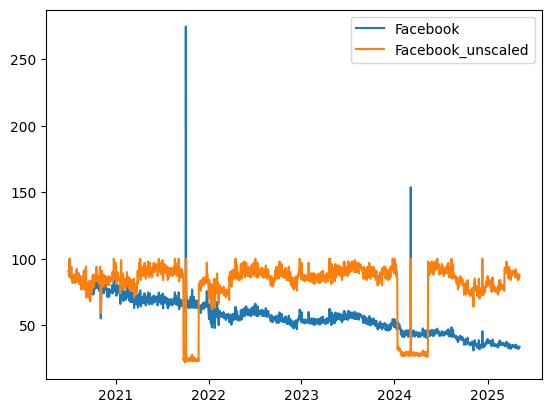

In [36]:
plt.plot(us_table_final['date'], us_table_final['Facebook'], label = 'Facebook')
plt.plot(us_table_final['date'], us_table_final['Facebook_unscaled'], label = 'Facebook_unscaled')
plt.legend()

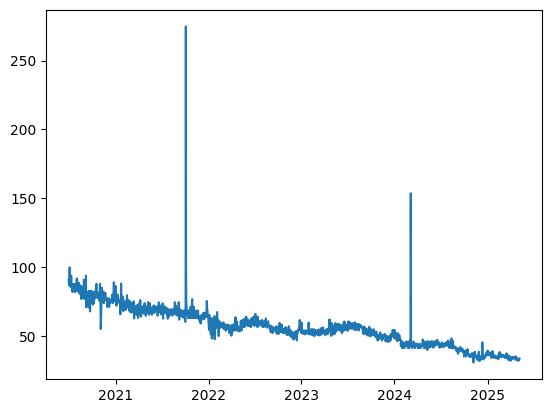

In [37]:
plt.plot(us_table_final['date'], us_table_final['Facebook'], label = 'Facebook')

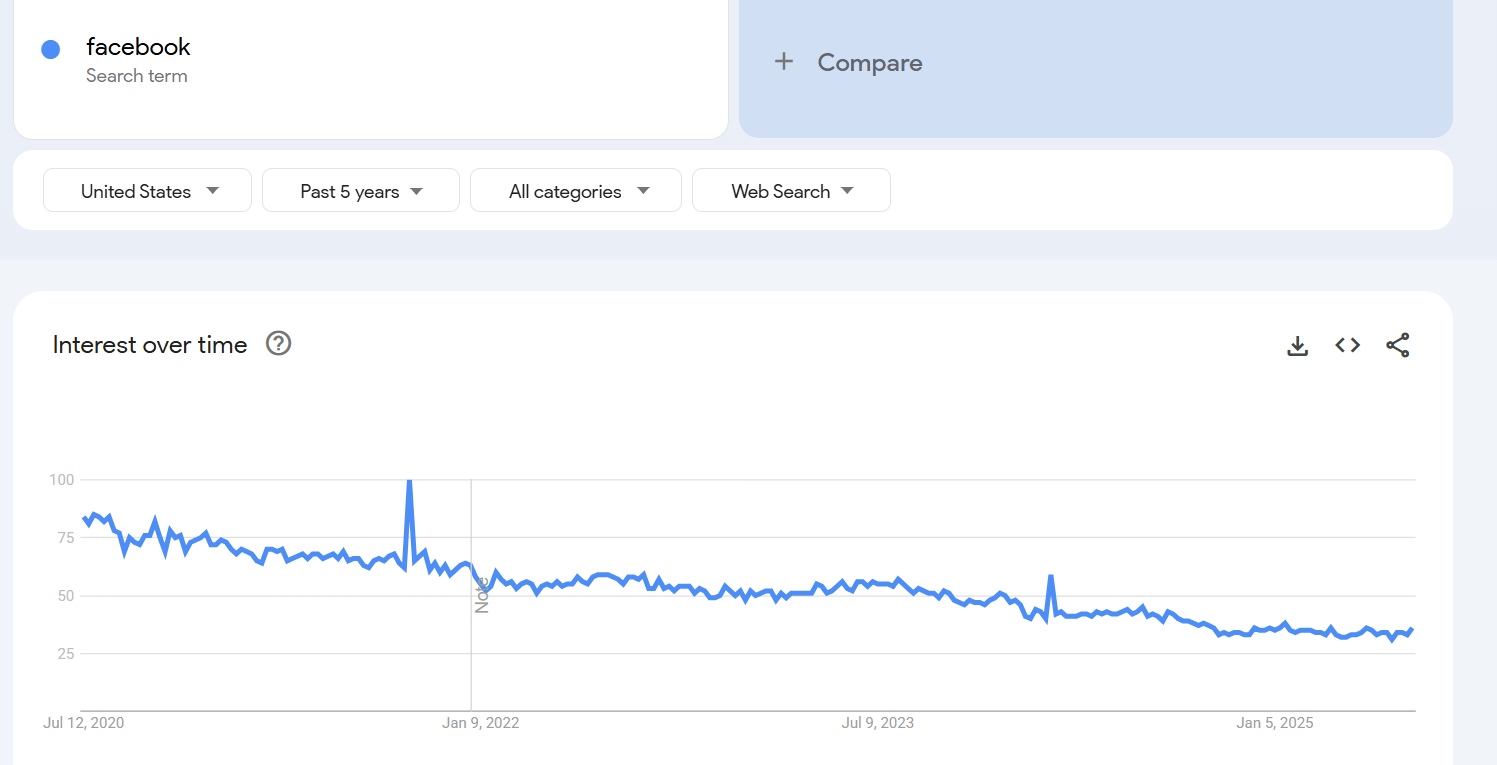

In [38]:
from IPython.display import Image
Image("Facebook 5 years.png")

In [39]:
y = us_table_final.filter((us_table_final['date'] > datetime.datetime(2021, 10, 3)) & (us_table_final['date'] < datetime.datetime(2021, 10, 11)))

In [40]:
y['Facebook'].mean()

102.82713982216056